In [3]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
max_before_tempering_is_one = max([int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1]) for idx in range(n)]) + 1

In [4]:
for idx in range(n):
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\theta_t^{\star} (=\rho)$')
plt.xlabel(r"Iteration $t$")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.savefig(DIR+"AR_optimal_parameter.png")

NameError: name 'max_before_tempering_is_one' is not defined

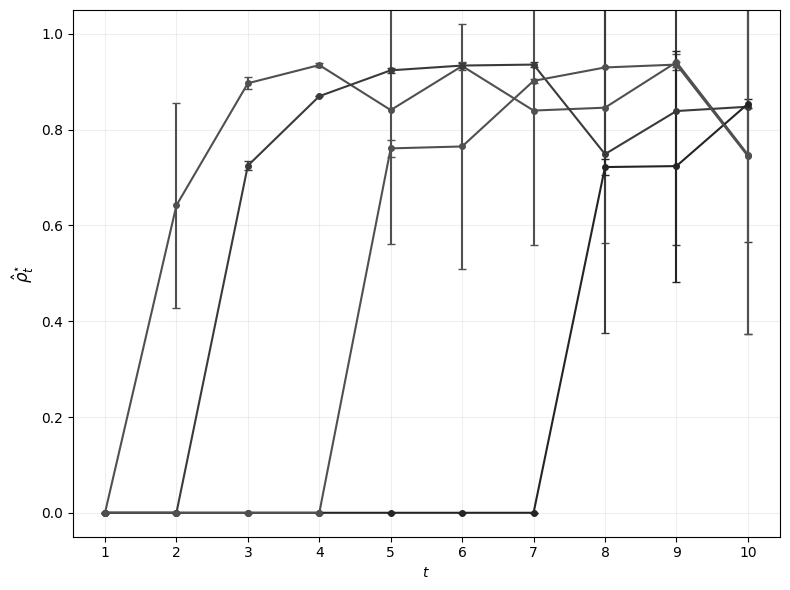

In [7]:
max_iter = 10
colors = ['#505050', '#3A3A3A', '#242424']  # Using your gray palette

fig, ax = plt.subplots(figsize=(8, 6))
for idx in range(n):
    x_axis = range(1, 1 + max_iter)
    params = PKLs[idx]['res'][3][:, :max_iter]
    yerr = np.minimum(np.std(params, axis=0).squeeze(), 1.0)  # Cap error at 1
    
    plt.errorbar(x_axis, np.mean(params, axis=0).squeeze(), yerr=yerr,
                color=colors[idx % len(colors)], 
                linewidth=1.5, 
                marker='o',
                markersize=4,
                capsize=3)

plt.ylabel(r'$\hat{\rho}_t^{\star}$', fontsize=12)
plt.xlabel(r'$t$')
plt.ylim(-0.05, 1.05)
plt.xticks(range(1, max_iter + 1))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(DIR + "AR_optimal_parameter.pdf", bbox_inches='tight')

/tmp/ipykernel_435829/3108084085.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


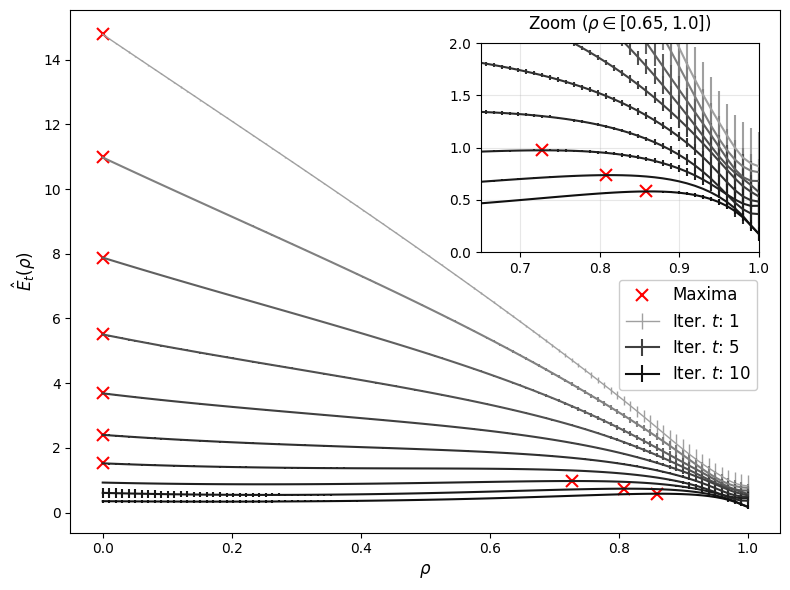

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

GRID_ESJD = np.linspace(0, 1, 100)
idx = 2
fig, ax = plt.subplots(figsize=(8, 6))
grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]

grays_dark = [
    "#A0A0A0",  # New lightest gray (much darker than original)
    "#808080",  # Mid-gray
    "#606060",
    "#505050",
    "#404040",
    "#303030",
    "#282828",
    "#202020",
    "#181818",
    "#101010",   # Almost black
    "#080808"    # Near-black
]

max_iter = 10

# Main plot
for j in range(max_iter):
    criteria_function = PKLs[idx]['res'][5]
    mean = criteria_function[:,j].mean(axis=0)
    std = criteria_function[:,j].std(axis=0)
    
    label = fr"Iter. $t$: {j+1}" 
    ax.errorbar(GRID_ESJD, mean, yerr=std,
               color=grays_dark[j],
               linestyle="solid",
               linewidth=1.5 if j >= 1 else 1.0,
               label=label if j in [0, 4, 9] else None)

    
    idx_max = np.argmax(mean)
    ax.plot(GRID_ESJD[idx_max], mean[idx_max],
        'x', color='red', markersize=8, markeredgewidth=1.5,
        label='Maxima' if j == 1 else None)

# Create inset axes
ax_inset = inset_axes(ax, width="40%", height="40%", loc=1,
                     bbox_to_anchor=(0, -0.05, 0.98, 1),
                     bbox_transform=ax.transAxes)

# Plot curves and mark maxima in inset
for j in range(max_iter): 
    criteria_function = PKLs[idx]['res'][5]
    mean = criteria_function[:,j].mean(axis=0)
    std = criteria_function[:,j].std(axis=0)
    
    # Plot curve
    ax_inset.errorbar(GRID_ESJD, mean, yerr=std,
                    color=grays_dark[j],
                    linestyle="solid",
                    linewidth=1.5)
    
    # Find and mark maximum point
    mask = (GRID_ESJD >= 0.65) & (GRID_ESJD <= 1.0)
    idx_max = np.argmax(mean[mask])
    if j > 6:
        ax_inset.plot(GRID_ESJD[mask][idx_max], mean[mask][idx_max],
                     'x', color='red', markersize=8, markeredgewidth=1.5,
                     label='Maxima' if j == 3 else None)

# Inset formatting
ax_inset.set_xlim(0.65, 1.0)
ax_inset.set_ylim(0, 2)
ax_inset.grid(alpha=0.3)
ax_inset.set_title(r'Zoom ($\rho \in [0.65,1.0]$)',
                   pad=10, fontsize=12)

# Main plot formatting
ax.set_ylabel(r"$\hat{E}_t(\rho)$", fontsize=12)
ax.set_xlabel(r'$\rho$', fontsize=12)
ax.legend(framealpha=1, bbox_to_anchor=(0.98, 0.5), loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig(DIR+f"{PKL_titles[idx]}_ar_criteria_function.pdf", dpi=300, bbox_inches='tight')

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_435829/3211575395.py:4: SyntaxWarning: invalid escape sequence '\s'
  """# Configuration


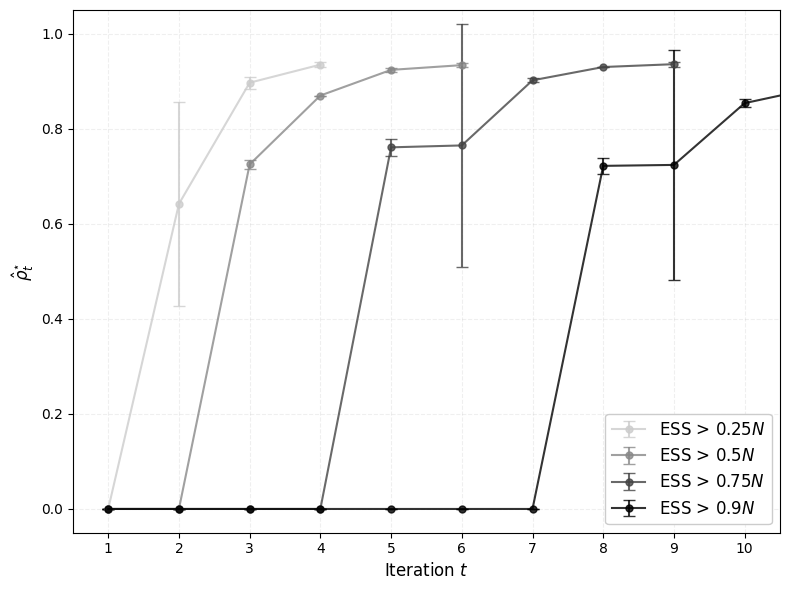

In [8]:
colors =  ["#CCCCCC", "#888888", "#000000", "#444444"]

fig, ax = plt.subplots(figsize=(8, 6))
"""# Configuration
idx = 0
T = 10
max_iter = 10
d = PKLs[idx]['config']['dim']
tau = PKLs[idx]['config']['problem']['tau']
sigma = np.sqrt((tau**(-2)-1)**(-1))
gamma = 1.
alpha = tau**(-2) - 1
critical_temperature = 33*1 / 2 * sigma ** 2 / d # assuming C = np.eye(dim)
realised_temperatures = PKLs[idx]['res'][6].mean(axis=0)

#exact
def rho_exact(lmbda):
    return np.sqrt(np.maximum(1-critical_temperature/lmbda, 0))
#Heuristic
def rho(lmbda):
    return np.sqrt(1-((sigma**2 ) / (gamma*lmbda + sigma**2))**2 )
def lmbda(t, tau):
    return np.minimum(1, -tau**2 / (tau**2-1) * (np.exp(np.sqrt(2/d)*t)-1))
t = np.arange(0, T)


# Theory curves (consistent with your previous style)
t = np.arange(0, T)
heuristic_curve = plt.plot(range(1, T+1), 
                         rho(realised_temperatures)[:T],
                         color=colors['heuristic'],
                         linestyle='--',
                         linewidth=2,
                         marker=None,  # No markers to match previous style
                         label=r"Titsias, Omiros' heuristic")[0]

exact_curve = plt.plot(range(1, T+1),
                      rho_exact(realised_temperatures)[:T],
                      color=colors['exact'],
                      linestyle='--',
                      linewidth=2,
                      marker=None,
                      label=r"$\sqrt{1-\hat{\lambda}_{\text{C}}/\lambda_t}, \lambda_t\geq \hat{\lambda}_{\text{C}}$")[0]
"""

order_index_by_ess = [0, 1, 3, 2]

# Empirical data (matches your errorbar style)
for idx in order_index_by_ess:
    max_before_tempering_is_one = int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1]) + 1
    x_axis = range(1, 1 + max_before_tempering_is_one)
    params = PKLs[idx]['res'][3][:, :max_before_tempering_is_one]
    yerr = np.minimum(np.std(params, axis=0).squeeze(), 1.0)
    
    empirical = plt.errorbar(x_axis,
                           np.mean(params, axis=0).squeeze(),
                           yerr=yerr,
                           color=colors[idx],
                           linewidth=1.5, 
                           marker='o',
                           markersize=5,
                           capsize=4,
                           alpha=0.8,
                           label=rf"ESS > {PKLs[idx]['config']['target_ess']}$N$")

# Formatting (consistent with your previous plots)
plt.ylabel(r'$\hat{\rho}^{\star}_t$', fontsize=12)
plt.xlabel(r'Iteration $t$', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xlim(0.5, 10.5)
plt.xticks(range(1, max_iter + 1))

# Light grid like previous plots
plt.grid(True, linestyle='--', alpha=0.2)
ax.legend(framealpha=1, loc='lower right', fontsize=12)

# Tight layout and save (consistent settings)
plt.tight_layout()
plt.savefig(DIR + "AR_optimal_parameter_comparison_consistent.pdf", dpi=300,
           bbox_inches='tight')